In [1]:
import csv
import os
import math

import matplotlib.pyplot as plt

# Labwork 1

In [2]:
def f(x):
  return x**2


def df(x):
  return 2*x


def gradient_descent_eg(x0, lr, iterations):
  x = x0
  results = []

  for t in range(1, iterations + 1):
    grad = df(x)
    x = x - lr * grad
    fx = f(x)
    results.append([t, x, fx])
    print(f"Time {t}: x = {x:.4f}, f(x) = {fx:.4f}")

  return x, results

In [3]:
x0 = 10
Lr = 0.1
iterations = 10

final_x, results = gradient_descent_eg(x0, Lr, iterations)

Time 1: x = 8.0000, f(x) = 64.0000
Time 2: x = 6.4000, f(x) = 40.9600
Time 3: x = 5.1200, f(x) = 26.2144
Time 4: x = 4.0960, f(x) = 16.7772
Time 5: x = 3.2768, f(x) = 10.7374
Time 6: x = 2.6214, f(x) = 6.8719
Time 7: x = 2.0972, f(x) = 4.3980
Time 8: x = 1.6777, f(x) = 2.8147
Time 9: x = 1.3422, f(x) = 1.8014
Time 10: x = 1.0737, f(x) = 1.1529


# Labwork 2

In [4]:
def read_csv(file_path):
  X = []
  y = []

  with open(file_path, 'r') as file:
    reader = csv.reader(file)

    for row in reader:
      X.append(float(row[0]))
      y.append(float(row[1]))

  return X, y

In [5]:
def compute_gradients(X, y, w1, w0):
  n = len(X)

  dw1 = 0.0
  dw0 = 0.0

  for i in range(n):
    y_pred = w1 * X[i] + w0
    error = y_pred - y[i]

    dw1 += X[i] * error
    dw0 += error

  dw1 = (2 / n) * dw1
  dw0 = (2 / n) * dw0

  return dw1, dw0


def loss(data, w0, w1):
  N = len(data)
  Z = 0.0

  for xi, yi in data:
    y_pred = w1 * xi + w0
    Z += (y_pred - yi) ** 2

  return Z / N


def gradient_descent_with_loss(X, y, lr, Time, show=True):
  w1 = 0.0
  w0 = 0.0

  history = []
  data = list(zip(X, y))

  for times in range(1, Time + 1):
    dw1, dw0 = compute_gradients(X, y, w1, w0)

    w1 = w1 - lr * dw1
    w0 = w0 - lr * dw0

    current_loss = loss(data, w0, w1)
    history.append([times, w1, w0, current_loss])

    if show == True:
      if times <= 10 or times % 10000 == 0:
        print(f"Time {times}: w0 = {w0:.4f}, w1 = {w1:.4f}, loss = {current_loss:.6f}")

    if current_loss > 1000000:
      break

  return w1, w0, history

In [6]:
file_path = 'lr(1).csv'

if os.path.exists(file_path) == False:
  file_path = '/mnt/data/lr(1).csv'

X, y = read_csv(file_path)

print('X =', X)
print('y =', y)

X = [10.0, 20.0, 40.0, 60.0, 80.0]
y = [55.0, 80.0, 100.0, 120.0, 150.0]


In [7]:
w1, w0, history = gradient_descent_with_loss(X, y, lr=0.0004, Time=50000)

print('Final result:')
print(f'w1 = {w1:.6f}')
print(f'w0 = {w0:.6f}')
print(f'y = {w1:.6f}x + {w0:.6f}')

Time 1: w0 = 0.0808, w1 = 4.0560, loss = 9960.122932
Time 2: w0 = 0.0253, w1 = 0.2569, loss = 8815.467224
Time 3: w0 = 0.0974, w1 = 3.8147, loss = 7811.355803
Time 4: w0 = 0.0500, w1 = 0.4821, loss = 6930.528170
Time 5: w0 = 0.1145, w1 = 3.6030, loss = 6157.843625
Time 6: w0 = 0.0742, w1 = 0.6797, loss = 5480.020924
Time 7: w0 = 0.1321, w1 = 3.4173, loss = 4885.409917
Time 8: w0 = 0.0979, w1 = 0.8530, loss = 4363.791234
Time 9: w0 = 0.1500, w1 = 3.2543, loss = 3906.200563
Time 10: w0 = 0.1213, w1 = 1.0049, loss = 3504.774515
Time 10000: w0 = 42.5028, w1 = 1.3574, loss = 27.057691
Time 20000: w0 = 47.3604, w1 = 1.2731, loss = 19.009144
Time 30000: w0 = 47.9160, w1 = 1.2634, loss = 18.903835
Time 40000: w0 = 47.9796, w1 = 1.2623, loss = 18.902457
Time 50000: w0 = 47.9869, w1 = 1.2622, loss = 18.902439
Final result:
w1 = 1.262211
w0 = 47.986866
y = 1.262211x + 47.986866


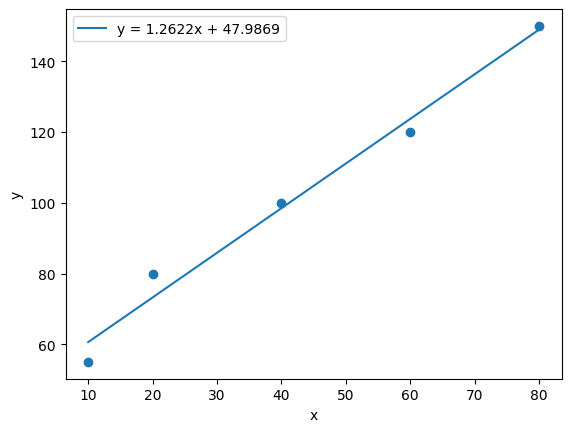

In [8]:
x_min = min(X)
x_max = max(X)
y_min = w1 * x_min + w0
y_max = w1 * x_max + w0

plt.scatter(X, y)
plt.plot([x_min, x_max], [y_min, y_max], label=f'y = {w1:.4f}x + {w0:.4f}')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.show()

In [9]:
learning_rates = [0.00001, 0.0001, 0.0004, 0.001]

for r in learning_rates:
  w1_temp, w0_temp, history_temp = gradient_descent_with_loss(X, y, lr=r, Time=50000, show=False)
  final_loss = history_temp[-1][3]
  steps = len(history_temp)

  print(f'r = {r}: w1 = {w1_temp:.4f}, w0 = {w0_temp:.4f}, loss = {final_loss:.4f}, steps = {steps}')

r = 1e-05: w1 = 1.8969, w0 = 11.4190, loss = 381.4041, steps = 50000


r = 0.0001: w1 = 1.3176, w0 = 44.7973, loss = 21.6618, steps = 50000
r = 0.0004: w1 = 1.2622, w0 = 47.9869, loss = 18.9024, steps = 50000
r = 0.001: w1 = -28.8146, w0 = -0.4482, loss = 2313896.1725, steps = 2


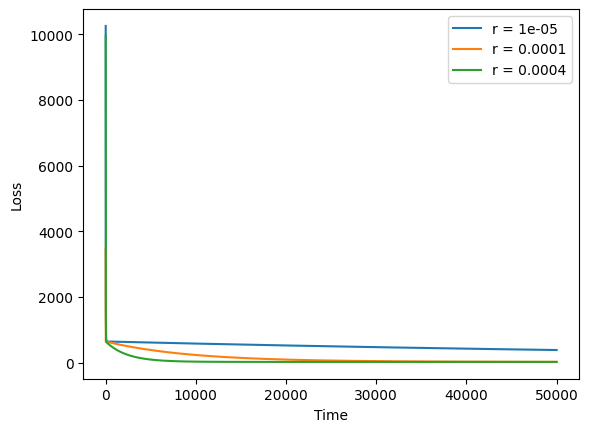

In [10]:
for r in [0.00001, 0.0001, 0.0004]:
  w1_temp, w0_temp, history_temp = gradient_descent_with_loss(X, y, lr=r, Time=50000, show=False)

  times = []
  losses = []

  for item in history_temp:
    times.append(item[0])
    losses.append(item[3])

  plt.plot(times, losses, label='r = ' + str(r))

plt.xlabel('Time')
plt.ylabel('Loss')
plt.legend()
plt.show()